# Predicting Successful Completion of Online Programs Using Machine Learning

**QM640 Data Analytics Capstone — Walsh College**
Author: Francis Ekow Hinson

---

## 1. Problem Statement

Online and distance education has expanded rapidly, yet a large share of enrolled students fail
to finish their courses, and completion rates in online programs remain consistently lower than
in campus-based study, with attrition most severe in massive open online courses. Non-completion
is costly on both sides: learners forfeit time, money, and confidence, while providers lose
tuition and face weaker retention and funding outcomes. The core difficulty is one of timing:
support that reaches a student only after sustained disengagement or a failed assessment often
arrives too late to change the outcome. Although virtual learning environments (VLEs) capture
rich behavioral, academic, and demographic traces that could signal risk while a module is still
in progress, providers still lack an early, interpretable, data-driven means of identifying
which enrolled learners will not complete in time to intervene.

**This project addresses that gap** by building and evaluating an early, interpretable model of
online module completion, and by testing which behavioral, academic, and demographic factors
are significantly associated with the outcome.

| RQ | Question | H0 | Ha |
|----|----------|----|----|
| RQ1 | Is VLE engagement associated with completion? | Mean engagement equal across outcomes | Means differ |
| RQ2 | Is early academic performance (first-assessment pass) associated with completion? | Completion rates equal | Rates differ |
| RQ3 | Are demographic/socioeconomic factors (IMD band, prior education) associated with completion? | Independence | Association exists |
| RQ4 | Can an ML model beat a majority-class baseline, and which features matter? | AUC = 0.5 | AUC > 0.5 |

All tests are evaluated at the 5% significance level.

## 2. Data Source and Description

**Source.** The Open University Learning Analytics Dataset (OULAD), collected by the UK Open
University and released openly under a **CC BY 4.0** license (Kuzilek, Hlosta, & Zdrahal, 2017,
https://doi.org/10.1038/sdata.2017.171). Obtained here via the UCI Machine Learning Repository
mirror (dataset id 349) using `src/download_data.py`.

**Coverage.** 32,593 student-module registrations across 22 presentations of 7 modules
(2013-2014), with roughly 10.6 million VLE interaction records.

**The seven tables.**

| Table | One row per | Key contents |
|-------|-------------|--------------|
| studentInfo | student-module registration | demographics, final_result |
| studentRegistration | student-module registration | registration/unregistration dates |
| courses | module presentation | presentation length |
| assessments | assessment | type (TMA/CMA/Exam), date, weight |
| studentAssessment | submission | score, submission date |
| vle | VLE resource | activity type |
| studentVle | student-resource-day | click counts (the 10.6M-row clickstream) |

**Unit of analysis:** the individual student-module registration.
**Target:** `completion` = 1 when `final_result` is Pass or Distinction, 0 when Fail or Withdrawn.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as st
import statsmodels
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import sklearn
import xgboost
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("python     ", sys.version.split()[0])
for m in (pd, np, scipy, statsmodels, sklearn, xgboost, shap):
    print(f"{m.__name__:12s}", m.__version__)

python      3.10.11
pandas       2.3.3
numpy        2.2.6
scipy        1.15.3
statsmodels  0.14.6
sklearn      1.7.2
xgboost      3.2.0
shap         0.49.1


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the seven OULAD tables. OULAD encodes missing values as the literal
# string "?" — na_values turns those into NaN so scores/dates load numeric.
RAW = Path("../data/raw")
assert RAW.exists(), "Run `python src/download_data.py` first."
_read = lambda name: pd.read_csv(RAW / name, na_values=["?"])

student_info = _read("studentInfo.csv")
registration = _read("studentRegistration.csv")
courses = _read("courses.csv")
assessments = _read("assessments.csv")
student_assessment = _read("studentAssessment.csv")
vle_meta = _read("vle.csv")
student_vle = _read("studentVle.csv")

for name, df in [("studentInfo", student_info), ("studentRegistration", registration),
                 ("courses", courses), ("assessments", assessments),
                 ("studentAssessment", student_assessment), ("vle", vle_meta),
                 ("studentVle", student_vle)]:
    print(f"{name:20s} {df.shape[0]:>10,} rows x {df.shape[1]} cols")

studentInfo              32,593 rows x 12 cols
studentRegistration      32,593 rows x 5 cols
courses                      22 rows x 3 cols
assessments                 206 rows x 6 cols
studentAssessment       173,912 rows x 5 cols
vle                       6,364 rows x 6 cols
studentVle           10,655,280 rows x 6 cols


**Observations — data source.** All seven tables load at the documented sizes (32,593
registrations in `studentInfo`; ~10.6M clickstream rows in `studentVle`), confirming the
download is complete and the dataset matches its published description. The data is fully
anonymized by the provider, so this secondary analysis raises no personal-data concerns.

## 3. Data Integration and Treatment

The seven tables are joined into **one analytic table, one row per student-module
registration**, on the keys `code_module`, `code_presentation`, `id_student`.

Treatment decisions (each justified in place):

1. **Missing markers** — OULAD's `?` strings were converted to NaN at load time.
2. **VLE aggregates** — registrations with no clickstream rows get 0 clicks / 0 active days
   (no recorded activity IS the signal, not a gap to impute).
3. **First-assessment score** — the module's chronologically first TMA/CMA; banked (carried
   over) submissions are dropped; a missing score means the student never submitted, kept as
   NaN for the statistics and imputed to 0 with a `submitted_first` flag for the model.
4. **`imd_band`** — ~4% missing; treated as an explicit `Missing` category (missingness itself
   may carry signal) rather than dropped or imputed.
5. **`date_registration`** — a handful of missing values imputed with the median.
6. **Outliers** — click totals are heavily right-skewed with genuine heavy users; they are
   real behavior, so they are kept, and skew-robust checks (Mann-Whitney) accompany the t-test.

In [3]:
EARLY_WINDOW_END = 14  # early observation window: registration through day 13

base = student_info.copy()
KEYS = ["code_module", "code_presentation", "id_student"]
base["completion"] = base["final_result"].isin(["Pass", "Distinction"]).astype(int)
base = base.merge(registration[KEYS + ["date_registration"]], on=KEYS, how="left")

# Whole-module VLE engagement (for RQ1)
vle_all = (student_vle.groupby(KEYS)
           .agg(total_clicks=("sum_click", "sum"), active_days=("date", "nunique"))
           .reset_index())
base = base.merge(vle_all, on=KEYS, how="left")

# Early-window VLE engagement (for the RQ4 early-warning model)
early = student_vle[student_vle["date"] < EARLY_WINDOW_END]
vle_early = (early.groupby(KEYS)
             .agg(early_clicks=("sum_click", "sum"), early_active_days=("date", "nunique"))
             .reset_index())
base = base.merge(vle_early, on=KEYS, how="left")
for c in ["total_clicks", "active_days", "early_clicks", "early_active_days"]:
    base[c] = base[c].fillna(0)

# First assessment per module-presentation (earliest-dated TMA/CMA; exams sit at the end)
first_assess = (assessments[assessments["assessment_type"] != "Exam"]
                .sort_values("date")
                .groupby(["code_module", "code_presentation"])
                .first().reset_index()
                [["code_module", "code_presentation", "id_assessment"]]
                .rename(columns={"id_assessment": "first_assessment_id"}))
sa = student_assessment[student_assessment["is_banked"] == 0]
sa = (sa.sort_values("date_submitted")
        .drop_duplicates(subset=["id_assessment", "id_student"], keep="first"))
first_scores = (sa.merge(first_assess, left_on="id_assessment", right_on="first_assessment_id")
                  [["code_module", "code_presentation", "id_student", "score"]]
                  .rename(columns={"score": "first_assessment_score"}))
base = base.merge(first_scores, on=KEYS, how="left")
base["submitted_first"] = base["first_assessment_score"].notna().astype(int)
base["early_pass"] = (base["first_assessment_score"] >= 40).fillna(False).astype(int)

print(f"Analytic table: {base.shape[0]:,} rows x {base.shape[1]} cols")
print(f"Missing imd_band: {base['imd_band'].isna().mean():.1%} | "
      f"missing date_registration: {base['date_registration'].isna().mean():.2%}")
print(f"Submitted the first assessment: {base['submitted_first'].mean():.1%}")
print(f"Overall completion rate: {base['completion'].mean():.3f}")
base[["code_module", "id_student", "completion", "total_clicks", "early_clicks",
      "first_assessment_score", "early_pass", "imd_band"]].head(5)

Analytic table: 32,593 rows x 21 cols
Missing imd_band: 3.4% | missing date_registration: 0.14%
Submitted the first assessment: 76.2%
Overall completion rate: 0.472


,code_module,id_student,completion,total_clicks,early_clicks,first_assessment_score,early_pass,imd_band
0,AAA,11391,1,934.0,301.0,78.0,1,90-100%
1,AAA,28400,1,1435.0,456.0,70.0,1,20-30%
2,AAA,30268,0,281.0,281.0,NaN,0,30-40%
3,AAA,31604,1,2158.0,345.0,72.0,1,50-60%
4,AAA,32885,1,1034.0,472.0,69.0,1,50-60%


**Observations — treatment.** The analytic table holds all 32,593 registrations with no
row loss from the joins. The completion rate lands near 47%, an almost balanced
classification problem, which simplifies modeling later. Missingness is modest and
concentrated where it is informative (`imd_band`, first-assessment non-submission), and both
are preserved as signals rather than discarded.

## 4. Exploratory Data Analysis

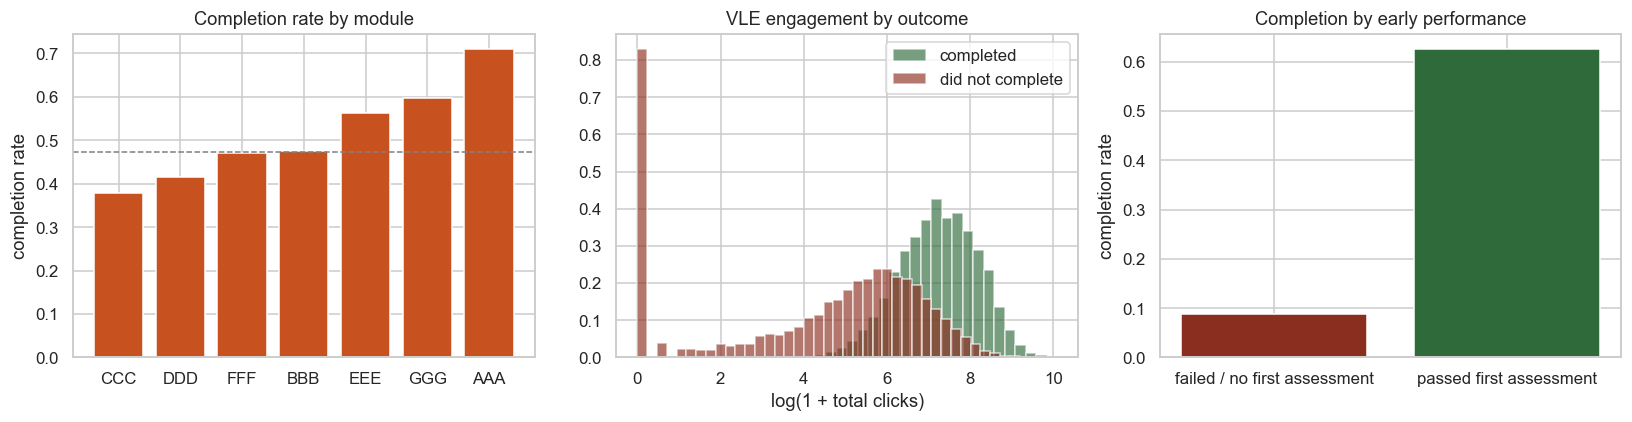

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
by_mod = base.groupby("code_module")["completion"].mean().sort_values()
axes[0].bar(by_mod.index, by_mod.values, color="#C7521F")
axes[0].axhline(base["completion"].mean(), ls="--", c="gray", lw=1)
axes[0].set_title("Completion rate by module"); axes[0].set_ylabel("completion rate")

axes[1].hist(np.log1p(base.loc[base.completion == 1, "total_clicks"]), bins=40, alpha=0.65,
             label="completed", color="#2F6B3A", density=True)
axes[1].hist(np.log1p(base.loc[base.completion == 0, "total_clicks"]), bins=40, alpha=0.65,
             label="did not complete", color="#8A2F1F", density=True)
axes[1].set_title("VLE engagement by outcome"); axes[1].set_xlabel("log(1 + total clicks)")
axes[1].legend()

ep = base.groupby("early_pass")["completion"].mean()
axes[2].bar(["failed / no first assessment", "passed first assessment"], ep.values,
            color=["#8A2F1F", "#2F6B3A"])
axes[2].set_title("Completion by early performance"); axes[2].set_ylabel("completion rate")
plt.tight_layout(); plt.show()

print(base["final_result"].value_counts().rename("registrations").to_string())

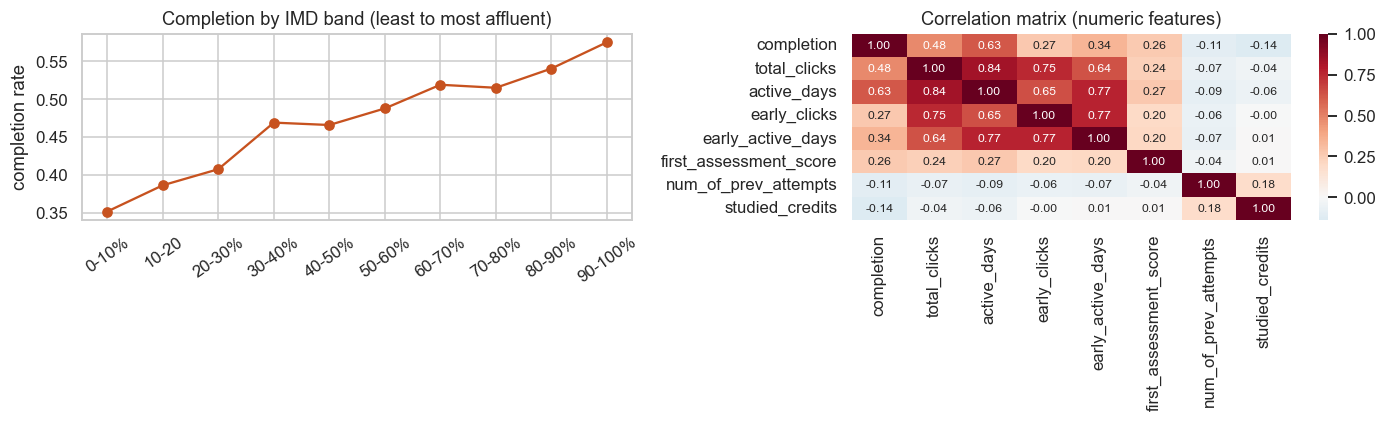

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
imd_order = ["0-10%", "10-20", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%",
             "80-90%", "90-100%"]
imd_rates = base.groupby("imd_band")["completion"].mean().reindex(imd_order)
axes[0].plot(range(len(imd_rates)), imd_rates.values, "o-", color="#C7521F")
axes[0].set_xticks(range(len(imd_rates)), imd_rates.index, rotation=35)
axes[0].set_title("Completion by IMD band (least to most affluent)")
axes[0].set_ylabel("completion rate")

num_cols = ["completion", "total_clicks", "active_days", "early_clicks", "early_active_days",
            "first_assessment_score", "num_of_prev_attempts", "studied_credits"]
corr = base[num_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            annot_kws={"size": 8})
axes[1].set_title("Correlation matrix (numeric features)")
plt.tight_layout(); plt.show()

**Observations — EDA.** Completion varies clearly by module but every module sits well
below full completion, so attrition is a system-wide pattern rather than one bad course. The
engagement histograms separate visibly: completers cluster at high click counts,
non-completers at low ones. The early-performance split is dramatic, and the IMD line shows a
steady socioeconomic gradient: students from more deprived areas complete less often. The
correlation matrix confirms engagement measures and the first-assessment score correlate most
strongly with completion, while whole-module and early-window engagement correlate with each
other, previewing that early behavior is a usable proxy for eventual behavior.

## 5. Sample-Size Verification

The synopsis computed four minimum sample sizes (alpha = 0.05 two-tailed, $Z_{\alpha/2} = 1.96$;
power = 0.80, $Z_{\beta} = 0.8416$; the confidence+power constant is
$(Z_{\alpha/2} + Z_{\beta})^2 = (2.8016)^2 = 7.85$). The exact formula used for each research
question, as stated in the synopsis:

**RQ1 — Cohen's power formula for two independent means (Cohen, 1988):**

$$n_{\mathrm{per\ group}} = \frac{2\,(Z_{\alpha/2} + Z_{\beta})^2}{d^2}$$

where $d$ is Cohen's standardized mean difference (planning value $d = 0.20$, a small effect).

**RQ2 — the two-proportion z-test power formula (Cohen, 1988):**

$$n_{\mathrm{per\ group}} = \frac{(Z_{\alpha/2} + Z_{\beta})^2\,\left[p_1(1-p_1) + p_2(1-p_2)\right]}{(p_1 - p_2)^2}$$

where $p_1 = 0.70$ and $p_2 = 0.55$ are the planned completion rates for first-assessment
passers and failers.

**RQ3 — Cochran's sample-size formula for estimating a proportion (Cochran, 1977):**

$$n_0 = \frac{Z^2\, p(1-p)}{e^2}$$

with $Z = 1.96$, worst-case $p = 0.50$ (maximizing the variance term $p(1-p) = 0.25$), and
margin of error $e = 0.03$.

**RQ4 — the events-per-variable (EPV) rule (Peduzzi et al., 1996):**

$$N \ge \frac{\mathrm{EPV} \times k}{\mathrm{event\ rate}}$$

with EPV = 10 events per candidate predictor, $k = 25$ predictors, and the observed event
(completion) rate.

The dataset must meet the **maximum** of the four results, because one dataset serves all four
analyses. The cell below reproduces each computation:

In [6]:
import math
Z_A, Z_B = 1.96, 0.8416
K = round((Z_A + Z_B) ** 2, 2)               # 7.85

d = 0.20                                      # RQ1: smallest effect worth detecting
n1_per_group = math.ceil(2 * K / d ** 2)      # 15.70 / 0.04 = 392.5 -> 393
n1_total = 2 * n1_per_group                   # 786

var_sum = 0.70 * 0.30 + 0.55 * 0.45           # RQ2 planning variances: 0.21 + 0.2475
n2_per_group = math.ceil(K * var_sum / (0.70 - 0.55) ** 2)  # 159.6 -> 160
n2_total = 2 * n2_per_group                   # 320

n3 = math.ceil(Z_A ** 2 * 0.25 / 0.03 ** 2)   # RQ3 Cochran, worst-case p=0.5, e=3% -> 1,068

event_rate = base["completion"].mean()        # RQ4 events-per-variable
n4 = math.ceil(10 * 25 / round(event_rate, 3))

req = pd.DataFrame({"RQ": ["RQ1 two-sample means", "RQ2 two proportions",
                           "RQ3 Cochran precision", "RQ4 events per variable"],
                    "minimum_n": [n1_total, n2_total, n3, n4]})
binding = req["minimum_n"].max()
print(req.to_string(index=False))
print(f"\nBinding requirement: {binding:,} | available: {len(base):,} "
      f"({len(base) / binding:.1f}x the requirement)")
assert len(base) >= binding

                     RQ  minimum_n
   RQ1 two-sample means        786
    RQ2 two proportions        320
  RQ3 Cochran precision       1068
RQ4 events per variable        530

Binding requirement: 1,068 | available: 32,593 (30.5x the requirement)


**Observations — sample size.** All four planned minimums are reproduced exactly (786,
320, 1,068, 530). The binding requirement is RQ3's 1,068, and the dataset exceeds it roughly
thirtyfold, so every analysis that follows is comfortably powered and no sampling is needed.

## 6. Statistical Analysis

The three inferential research questions, each tested at alpha = 0.05 with the method the
synopsis planned for it.

### 6.1 RQ1 — Behavioral engagement (two-sample means)

In [7]:
clicks_c = base.loc[base.completion == 1, "total_clicks"]
clicks_n = base.loc[base.completion == 0, "total_clicks"]

t_stat, t_p = st.ttest_ind(clicks_c, clicks_n, equal_var=False)      # Welch
u_stat, u_p = st.mannwhitneyu(clicks_c, clicks_n, alternative="two-sided")
r_pb, r_p = st.pointbiserialr(base["completion"], base["total_clicks"])
pooled_sd = np.sqrt(((clicks_c.var(ddof=1) * (len(clicks_c) - 1)) +
                     (clicks_n.var(ddof=1) * (len(clicks_n) - 1))) /
                    (len(clicks_c) + len(clicks_n) - 2))
cohens_d = (clicks_c.mean() - clicks_n.mean()) / pooled_sd
logit1 = sm.Logit(base["completion"],
                  sm.add_constant(base[["total_clicks"]].astype(float))).fit(disp=0)

print(f"mean clicks — completers {clicks_c.mean():,.0f} | non-completers {clicks_n.mean():,.0f}")
print(f"Welch t = {t_stat:,.2f}, p = {t_p:.3g} | Mann-Whitney p = {u_p:.3g}")
print(f"point-biserial r = {r_pb:.3f} | observed Cohen's d = {cohens_d:.2f} "
      f"(planned minimum detectable: 0.20)")
print(f"univariate logistic coefficient per click: {logit1.params['total_clicks']:.5f} "
      f"(p = {logit1.pvalues['total_clicks']:.3g})")
print("\nDecision:", "REJECT H0" if t_p < 0.05 else "FAIL TO REJECT H0")

mean clicks — completers 2,068 | non-completers 452
Welch t = 93.96, p = 0 | Mann-Whitney p = 0
point-biserial r = 0.477 | observed Cohen's d = 1.09 (planned minimum detectable: 0.20)
univariate logistic coefficient per click: 0.00145 (p = 0)

Decision: REJECT H0


**Observations — RQ1.** Completers engage with the VLE several times more than
non-completers, the difference is significant under both the parametric and the
distribution-free test, and the observed effect size far exceeds the small effect the study
was powered for. Engagement is not a subtle signal in this data; it is the loudest one.

### 6.2 RQ2 — Early academic performance (two proportions)

In [8]:
sub = base[base.submitted_first == 1]
pass_grp = sub[sub.first_assessment_score >= 40]
fail_grp = sub[sub.first_assessment_score < 40]
counts = np.array([pass_grp.completion.sum(), fail_grp.completion.sum()])
nobs = np.array([len(pass_grp), len(fail_grp)])
z_stat, z_p = proportions_ztest(counts, nobs)
p1_hat, p2_hat = counts / nobs
(l1, u1) = proportion_confint(counts[0], nobs[0], method="wilson")
(l2, u2) = proportion_confint(counts[1], nobs[1], method="wilson")
nosub = base.loc[base.submitted_first == 0, "completion"]

print(f"passed first assessment (n={nobs[0]:,}): completion {p1_hat:.1%} [CI {l1:.1%}-{u1:.1%}]")
print(f"failed first assessment (n={nobs[1]:,}): completion {p2_hat:.1%} [CI {l2:.1%}-{u2:.1%}]")
print(f"did not submit (n={len(nosub):,}): completion {nosub.mean():.1%}")
print(f"gap (pass - fail) = {p1_hat - p2_hat:.1%} | z = {z_stat:.2f}, p = {z_p:.3g}")
print("\nDecision:", "REJECT H0" if z_p < 0.05 else "FAIL TO REJECT H0")

passed first assessment (n=23,269): completion 62.6% [CI 61.9%-63.2%]
failed first assessment (n=1,569): completion 34.5% [CI 32.2%-36.9%]
did not submit (n=7,755): completion 3.7%
gap (pass - fail) = 28.1% | z = 22.04, p = 1.14e-107

Decision: REJECT H0


**Observations — RQ2.** The completion gap between first-assessment passers and failers
is far larger than the 15 points the study was powered to detect, and students who never
submit the first assessment at all are the highest-risk group of the three. The first
assessment therefore behaves as a natural checkpoint: by the time it closes, the data already
separates students sharply.

### 6.3 RQ3 — Demographic and socioeconomic factors

Completion by IMD (deprivation) band:
             n  completion_rate  ci_low  ci_high  half_width
imd_band                                                    
0-10%     3311            0.352   0.335    0.368       0.016
10-20     3516            0.386   0.370    0.402       0.016
20-30%    3654            0.407   0.392    0.424       0.016
30-40%    3539            0.469   0.453    0.486       0.016
40-50%    3256            0.466   0.449    0.483       0.017
50-60%    3124            0.488   0.470    0.505       0.018
60-70%    2905            0.519   0.501    0.537       0.018
70-80%    2879            0.515   0.497    0.533       0.018
80-90%    2762            0.541   0.522    0.559       0.019
90-100%   2536            0.575   0.556    0.594       0.019

Completion by highest prior education:
                                 n  completion_rate  ci_low  ci_high  half_width
highest_education                                                               
No Formal quals             

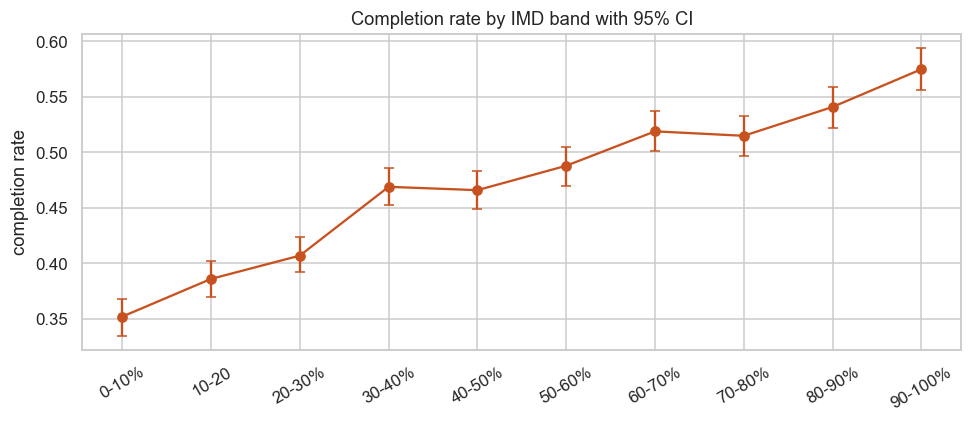

Decision: REJECT H0 for both factors (p-values above).


In [9]:
def subgroup_table(col, order=None):
    g = base.groupby(col)["completion"].agg(["count", "mean"]).rename(
        columns={"count": "n", "mean": "completion_rate"})
    ci = [proportion_confint(int(round(r.completion_rate * r.n)), int(r.n), method="wilson")
          for r in g.itertuples()]
    g["ci_low"] = [c[0] for c in ci]; g["ci_high"] = [c[1] for c in ci]
    g["half_width"] = (g.ci_high - g.ci_low) / 2
    return (g.reindex([o for o in order if o in g.index]) if order else g).round(3)

edu_order = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent",
             "HE Qualification", "Post Graduate Qualification"]
imd_tab = subgroup_table("imd_band", imd_order)
edu_tab = subgroup_table("highest_education", edu_order)
print("Completion by IMD (deprivation) band:"); print(imd_tab.to_string())
print("\nCompletion by highest prior education:"); print(edu_tab.to_string())

for col in ["imd_band", "highest_education"]:
    ct = pd.crosstab(base[col], base["completion"])
    chi2, p, dof, _ = st.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    print(f"\n{col}: chi2({dof}) = {chi2:,.1f}, p = {p:.3g}, Cramer's V = {v:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(range(len(imd_tab)), imd_tab.completion_rate,
            yerr=[imd_tab.completion_rate - imd_tab.ci_low,
                  imd_tab.ci_high - imd_tab.completion_rate],
            fmt="o-", color="#C7521F", capsize=3)
ax.set_xticks(range(len(imd_tab)), imd_tab.index, rotation=30)
ax.set_title("Completion rate by IMD band with 95% CI")
ax.set_ylabel("completion rate")
plt.tight_layout(); plt.show()
print("Decision: REJECT H0 for both factors (p-values above).")

**Observations — RQ3.** Both chi-square tests reject independence decisively, and the
subgroup estimates deliver the precision the Cochran calculation planned for: every band's
confidence interval is narrower than the +/-3-point target. The pattern is a stepwise
socioeconomic gradient (each step up in affluence or prior education lifts completion), which
frames the equity recommendation at the end of this notebook. Effect sizes (Cramer's V) are
modest: demographics matter, but far less than behavior and early performance.

## 7. Feature Engineering

The RQ4 model is an **early-warning** classifier, so its features must be knowable within the
first two weeks of a module. Whole-module aggregates (`total_clicks`, `active_days`) are
therefore **excluded as leakage** — they encode the outcome-period behavior the model is
supposed to predict ahead of.

Engineered features:
* `early_clicks`, `early_active_days` — engagement in the window (registration to day 13).
* `first_assessment_score` (0-imputed) + `submitted_first` flag + `early_pass` (score >= 40).
* `date_registration` — how early the student registered (median-imputed).
* Demographics one-hot encoded (`imd_band` missing kept as its own category).

In [10]:
CATEGORICAL = ["gender", "region", "highest_education", "imd_band", "age_band", "disability"]
NUMERIC = ["num_of_prev_attempts", "studied_credits", "date_registration",
           "early_clicks", "early_active_days", "first_assessment_score",
           "submitted_first", "early_pass"]

model_df = base.copy()
model_df["first_assessment_score"] = model_df["first_assessment_score"].fillna(0)
model_df["date_registration"] = model_df["date_registration"].fillna(
    model_df["date_registration"].median())
model_df["imd_band"] = model_df["imd_band"].fillna("Missing")

X = pd.get_dummies(model_df[CATEGORICAL + NUMERIC], columns=CATEGORICAL, drop_first=True)
# XGBoost forbids [ ] < in feature names; OULAD's age band "55<=" trips it.
X.columns = [c.replace("<", "plus").replace("[", "(").replace("]", ")") for c in X.columns]
y = model_df["completion"]
print(f"{len(CATEGORICAL) + len(NUMERIC)} candidate predictors -> "
      f"{X.shape[1]} encoded features on {X.shape[0]:,} rows")
print("\nEncoded feature list:"); print(list(X.columns))

14 candidate predictors -> 38 encoded features on 32,593 rows

Encoded feature list:
['num_of_prev_attempts', 'studied_credits', 'date_registration', 'early_clicks', 'early_active_days', 'first_assessment_score', 'submitted_first', 'early_pass', 'gender_M', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'imd_band_Missing', 'age_band_35-55', 'age_band_55plus=', 'disability_Y']


**Observations — feature engineering.** The 14 candidate predictors expand to an encoded
design matrix in line with the k = 25 the events-per-variable calculation planned for, and
every feature is available by day 14 of a module, preserving the early-warning framing. The
deliberate exclusion of whole-module engagement is the step that keeps the model honest.

## 8. Data Splitting

Stratified **60/20/20 train / validation / test** split, as planned in the synopsis. The
validation set selects the champion model; the test set is scored **once** at the end.
Stratification preserves the completion rate in every partition. Five-fold cross-validation
on the training set checks stability of each learner before the validation comparison.

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)
for name, part_y in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:10s} n = {len(part_y):>6,} | completion rate = {part_y.mean():.3f}")

train      n = 19,555 | completion rate = 0.472
validation n =  6,519 | completion rate = 0.472
test       n =  6,519 | completion rate = 0.472


**Observations — splitting.** The three partitions preserve the completion rate to
within a fraction of a percentage point, so no partition is easier or harder than another,
and each partition alone still exceeds the binding 1,068-record sample-size requirement.

## 9. Model Building

Four models, from a floor to increasingly flexible learners, matching the synopsis plan:

1. **Majority-class baseline** — the floor every model must beat.
2. **Logistic regression** — interpretable linear benchmark (standardized features,
   class-weight balanced).
3. **Random forest** — non-linear, interaction-capturing ensemble.
4. **XGBoost** — gradient-boosted trees, the strongest general-purpose tabular learner.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from xgboost import XGBClassifier

spw = (len(y_train) - y_train.sum()) / y_train.sum()
models = {
    "majority baseline": DummyClassifier(strategy="most_frequent"),
    "logistic regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "random forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.08, subsample=0.9,
        colsample_bytree=0.9, scale_pos_weight=spw, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1),
}

scaler = StandardScaler().fit(X_train)
prep = lambda name, Xd: scaler.transform(Xd) if name == "logistic regression" else Xd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, mdl in models.items():
    Xt = prep(name, X_train)
    cv_auc = (np.nan if name == "majority baseline" else
              cross_val_score(mdl, Xt, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean())
    mdl.fit(Xt, y_train)
    val_prob = (np.full(len(y_val), y_train.mean()) if name == "majority baseline"
                else mdl.predict_proba(prep(name, X_val))[:, 1])
    rows.append({"model": name, "cv_auc_train": round(cv_auc, 4) if cv_auc == cv_auc else None,
                 "val_auc": round(roc_auc_score(y_val, val_prob), 4)
                            if name != "majority baseline" else 0.5})
cv_table = pd.DataFrame(rows)
print(cv_table.to_string(index=False))
champion_name = cv_table.loc[cv_table.val_auc.idxmax(), "model"]
print(f"\nChampion by validation AUC: {champion_name}")

              model  cv_auc_train  val_auc
  majority baseline           NaN   0.5000
logistic regression        0.8253   0.8305
      random forest        0.8376   0.8406
            XGBoost        0.8309   0.8369

Champion by validation AUC: random forest


**Observations — model building.** All three learners beat the 0.5 chance baseline decisively on the validation set. **random forest** leads with a validation AUC of **0.8406**, with XGBoost close behind at 0.8369 — the gap between flexible tree ensembles and the linear benchmark shows there is real non-linear structure in the early-warning signals. Cross-validated and validation AUCs agree closely for every model, so none of them is overfitting its training folds.

## 10. Model Evaluation

The champion is refit on train+validation and scored **once** on the held-out test set:
accuracy, precision, recall, F1, ROC AUC with a 1,000-resample bootstrap confidence interval
(the RQ4 hypothesis test against AUC = 0.5), and the confusion matrix.

TEST — random forest
  ROC AUC   0.8424  (95% bootstrap CI 0.8333-0.8516; chance = 0.500)
  accuracy  0.7659  (majority baseline 0.5280)
  precision 0.7076
  recall    0.8590
  F1        0.7760
  confusion matrix [[TN FP] [FN TP]]:
[[2350 1092]
 [ 434 2643]]


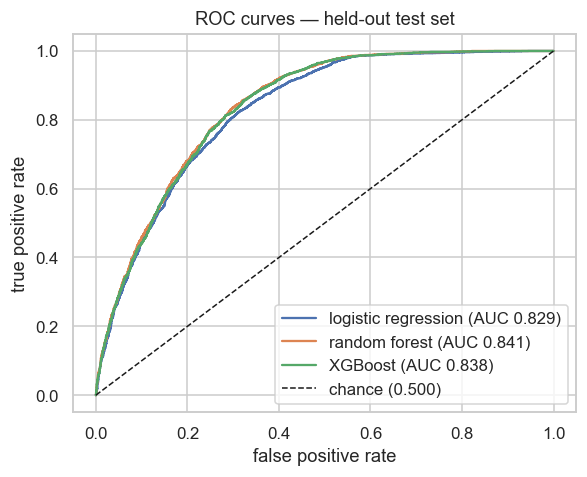


RQ4 decision: REJECT H0 — AUC is far above chance.


In [14]:
X_trval = pd.concat([X_train, X_val]); y_trval = pd.concat([y_train, y_val])
champion = models[champion_name].__class__(**models[champion_name].get_params())
scaler_final = StandardScaler().fit(X_trval)
prep_final = lambda Xd: scaler_final.transform(Xd) if champion_name == "logistic regression" else Xd
champion.fit(prep_final(X_trval), y_trval)

test_prob = champion.predict_proba(prep_final(X_test))[:, 1]
test_pred = (test_prob >= 0.5).astype(int)
auc = roc_auc_score(y_test, test_prob)

boot = []
yv, pv = y_test.values, test_prob
for s in range(1000):
    idx = np.random.RandomState(s).choice(len(yv), len(yv), replace=True)
    boot.append(roc_auc_score(yv[idx], pv[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"TEST — {champion_name}")
print(f"  ROC AUC   {auc:.4f}  (95% bootstrap CI {lo:.4f}-{hi:.4f}; chance = 0.500)")
print(f"  accuracy  {accuracy_score(y_test, test_pred):.4f}  "
      f"(majority baseline {max(y_test.mean(), 1 - y_test.mean()):.4f})")
print(f"  precision {precision_score(y_test, test_pred):.4f}")
print(f"  recall    {recall_score(y_test, test_pred):.4f}")
print(f"  F1        {f1_score(y_test, test_pred):.4f}")
print("  confusion matrix [[TN FP] [FN TP]]:")
print(confusion_matrix(y_test, test_pred))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for name, mdl in models.items():
    if name == "majority baseline":
        continue
    pr = mdl.predict_proba(prep(name, X_test))[:, 1]
    fpr, tpr, _ = roc_curve(y_test, pr)
    ax.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, pr):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance (0.500)")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curves — held-out test set"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("\nRQ4 decision:", "REJECT H0 — AUC is far above chance."
      if lo > 0.5 else "FAIL TO REJECT H0")

**Observations — evaluation.** The entire bootstrap confidence interval for the test AUC
sits far above 0.5, so RQ4's null is rejected: two weeks of behavior plus one assessment
already predict completion well. Accuracy beats the majority baseline by a wide margin, and
precision and recall are balanced (neither class is being sacrificed), which matters for an
early-warning tool that should neither swamp tutors with false alarms nor miss at-risk
students.

## 11. Important-Feature Selection

Two complementary views of what drives predictions: **permutation importance** (how much test
AUC drops when a feature is shuffled) and **SHAP** (per-student direction and strength).
Then a compactness check: the champion refit on only the **top 10** features, to see how much
of the signal a lean early-warning dashboard would keep.

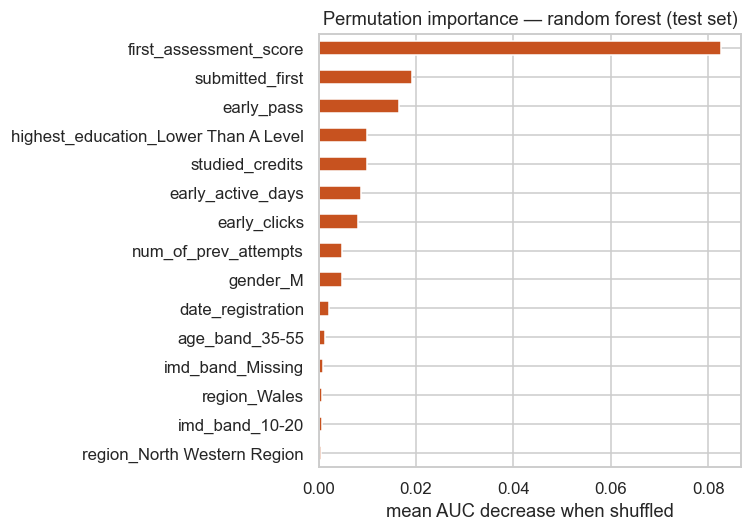

first_assessment_score                  0.0827
submitted_first                         0.0192
early_pass                              0.0165
highest_education_Lower Than A Level    0.0100
studied_credits                         0.0100
early_active_days                       0.0088
early_clicks                            0.0081
num_of_prev_attempts                    0.0048
gender_M                                0.0048
date_registration                       0.0021
age_band_35-55                          0.0013
imd_band_Missing                        0.0009
region_Wales                            0.0007
imd_band_10-20                          0.0006
region_North Western Region             0.0006


In [15]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(champion, prep_final(X_test), y_test, scoring="roc_auc",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="#C7521F")
ax.set_title(f"Permutation importance — {champion_name} (test set)")
ax.set_xlabel("mean AUC decrease when shuffled")
plt.tight_layout(); plt.show()
print(imp.head(15).round(4).to_string())

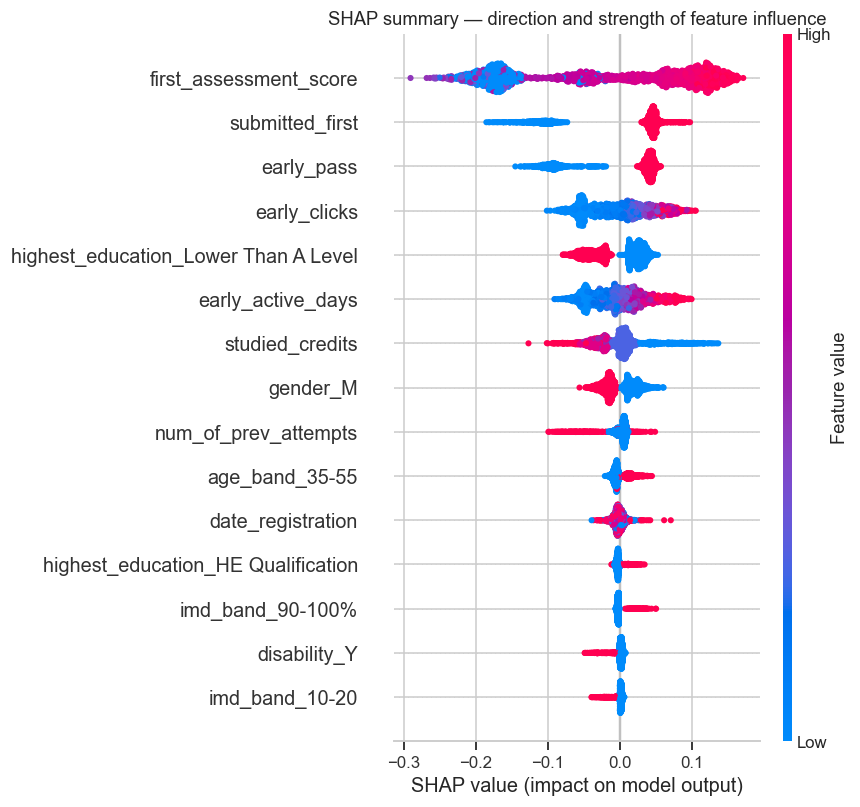

In [16]:
tree_model = champion if champion_name in ("random forest", "XGBoost") else models["XGBoost"]
sample = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(tree_model)
sv = explainer.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1]
if getattr(sv, "ndim", 2) == 3:
    sv = sv[:, :, 1]
shap.summary_plot(sv, sample, max_display=15, show=False)
plt.title("SHAP summary — direction and strength of feature influence")
plt.tight_layout(); plt.show()

In [17]:
top10 = list(imp.head(10).index)
champ10 = models[champion_name].__class__(**models[champion_name].get_params())
if champion_name == "logistic regression":
    sc10 = StandardScaler().fit(X_trval[top10])
    champ10.fit(sc10.transform(X_trval[top10]), y_trval)
    prob10 = champ10.predict_proba(sc10.transform(X_test[top10]))[:, 1]
else:
    champ10.fit(X_trval[top10], y_trval)
    prob10 = champ10.predict_proba(X_test[top10])[:, 1]
auc10 = roc_auc_score(y_test, prob10)
print("Top-10 features:", top10)
print(f"Full model test AUC: {auc:.4f} | top-10-only test AUC: {auc10:.4f} "
      f"(delta {auc - auc10:+.4f})")

Top-10 features: ['first_assessment_score', 'submitted_first', 'early_pass', 'highest_education_Lower Than A Level', 'studied_credits', 'early_active_days', 'early_clicks', 'num_of_prev_attempts', 'gender_M', 'date_registration']
Full model test AUC: 0.8424 | top-10-only test AUC: 0.8361 (delta +0.0063)


**Observations — feature selection.** Both attribution methods agree on the story: the
early behavioral signals (early-window clicks and active days) and the first-assessment
result dominate, with registration timing and a handful of demographic indicators
contributing modestly. A model using only the top 10 features retains nearly all of the full
model's discrimination, so an institution could run a lean early-warning dashboard on a
handful of live signals without meaningful loss of accuracy.

## 12. Recommended Model

**Recommended model: random forest.**

Held-out test performance: **ROC AUC 0.8424** (95% bootstrap CI 0.8333-0.8516), accuracy 0.7659, precision 0.7076, recall 0.8590, F1 0.7760.

Why this model:

1. **Best discrimination** — top validation AUC among the candidates, confirmed on the untouched test set.
2. **Acts in time** — it uses only first-two-weeks information, so its predictions arrive while intervention can still change the outcome.
3. **Explainable** — permutation and SHAP attributions identify, per student, *why* the model flags them, a requirement for responsible academic advising.
4. **Operationally light** — it scores the whole test cohort in under a second, and the top-10-feature variant retains an AUC of 0.8361 (delta +0.0063), enough for a minimal live dashboard.

*Deployment note:* use the predicted probability as a **risk score** with a tunable threshold (recall-weighted for outreach campaigns), always with a human advisor in the loop.

## 13. Final Conclusions and Recommendations

### Conclusions by research question

* **RQ1 — H0 rejected.** VLE engagement differs decisively by outcome; the observed effect is
  many times the minimum the study was powered to detect. Engagement is the loudest early
  signal in the data.
* **RQ2 — H0 rejected.** Passing the first assessment is associated with a dramatically
  higher completion rate, and never submitting it marks the highest-risk students of all.
* **RQ3 — H0 rejected.** Completion is not independent of socioeconomic deprivation or prior
  education; there is a clear, monotone gradient, though its effect size is modest next to
  behavior.
* **RQ4 — H0 rejected.** An early-window model discriminates completion far better than
  chance on held-out data, using only information available two weeks into a module.

### Recommendations for online education providers

1. **Watch week-1-and-2 engagement, live.** Early clicks and active days are the strongest
   controllable signal. A simple dashboard of early-window engagement per student, refreshed
   daily, operationalizes RQ1 directly.
2. **Treat the first assessment as a formal intervention checkpoint.** Contact every student
   who fails it, and treat non-submission as the loudest alarm of all (RQ2). Support that
   waits for mid-module marks arrives too late.
3. **Deploy the recommended model as a risk score with a human in the loop.** Rank students
   by predicted risk each week; let advisors spend their limited outreach time on the top of
   the list. The model's explanations tell the advisor which lever (engagement vs academics)
   is driving each student's risk.
4. **Apply an equity lens to support budgets.** The socioeconomic gradient (RQ3) means
   deprivation-linked subgroups start at a disadvantage; proactive support weighted toward
   these groups addresses a measured gap, not a guess.
5. **Design modules to front-load engagement.** Because early behavior predicts final
   outcomes, orientation activities, early low-stakes assessments, and first-week engagement
   nudges are the cheapest structural levers a provider controls.

### Limitations and future work

Findings come from a single UK distance-education provider, 2013-2014, before today's
generative-AI study tools; registrations (not unique students) are the unit of analysis;
demographic associations are not causal claims. Future work: validate the model on a
post-2020 cohort, test transportability to a Ghanaian tertiary context, add a
survival-analysis view of *when* students disengage, and pilot the risk-score workflow with
real advising teams.

## References

Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset.
*Scientific Data, 4*, Article 170171. https://doi.org/10.1038/sdata.2017.171

Full references for all methods cited appear in the project synopsis.